<a href="https://colab.research.google.com/github/sampabiet90/AIML/blob/LogicMojo-AI-ML-April26-sampa90/Clustering_K_means_and_Hierarchical.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Clustering/Country-data.csv')
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [5]:
df.shape

(167, 10)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [7]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


In [8]:
df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


In [9]:
df.duplicated().sum()

np.int64(0)

Peform EDA on dataset

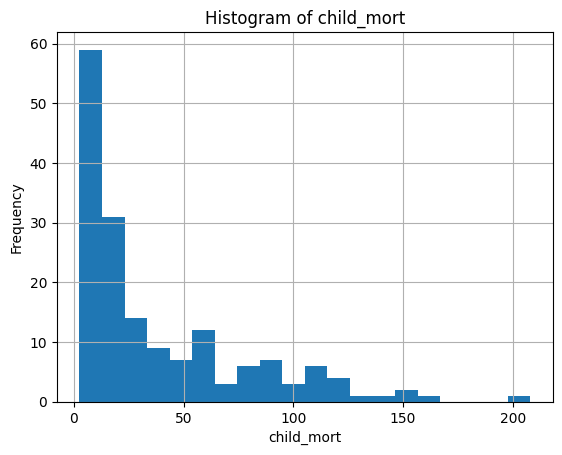

In [10]:
#Univariate Analysis
df['child_mort'].hist(bins=20)
plt.xlabel('child_mort')
plt.ylabel('Frequency')
plt.title('Histogram of child_mort')
plt.show()

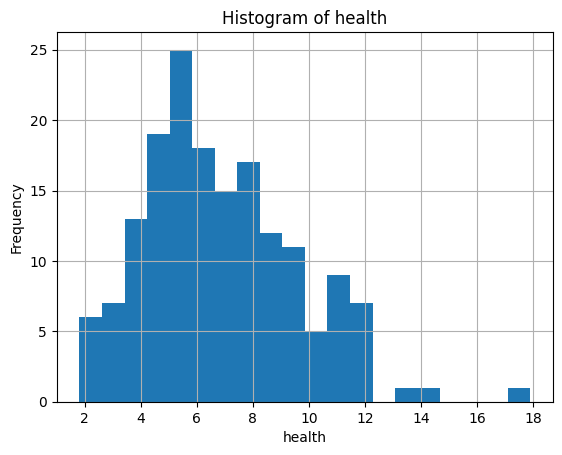

In [11]:
#Univariate Analysis
df['health'].hist(bins=20)
plt.xlabel('health')
plt.ylabel('Frequency')
plt.title('Histogram of health')
plt.show()

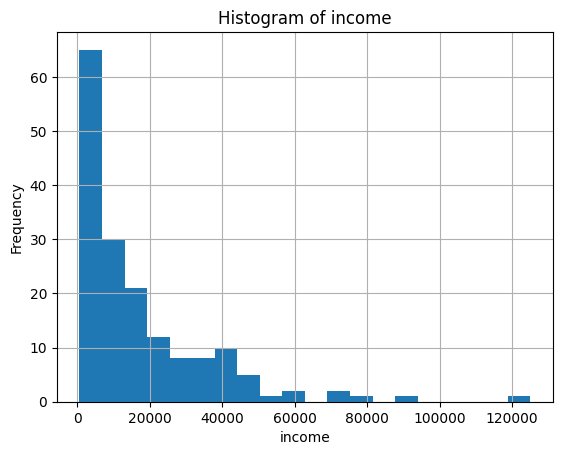

In [12]:
#Univariate Analysis
df['income'].hist(bins=20)
plt.xlabel('income')
plt.ylabel('Frequency')
plt.title('Histogram of income')
plt.show()

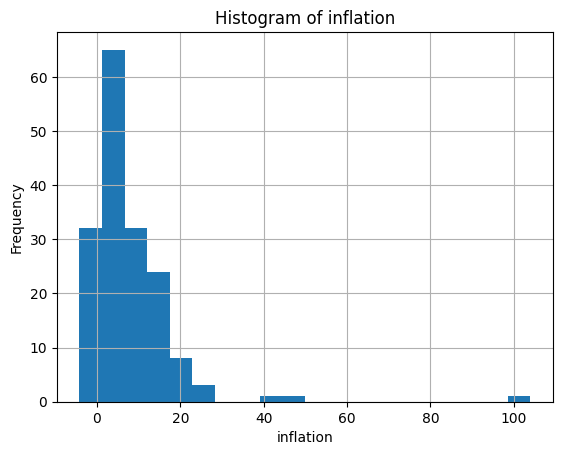

In [15]:
#Univariate Analysis
df['inflation'].hist(bins=20)
plt.xlabel('inflation')
plt.ylabel('Frequency')
plt.title('Histogram of inflation')
plt.show()

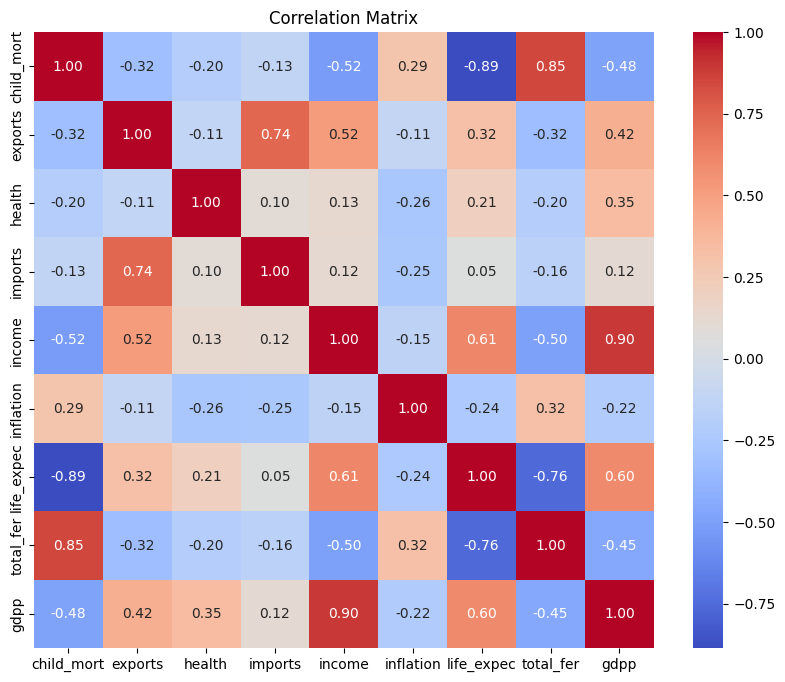

In [16]:
# corelation matrix
plt.figure(figsize=(10,8))
sns.heatmap(df.drop('country', axis=1).corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

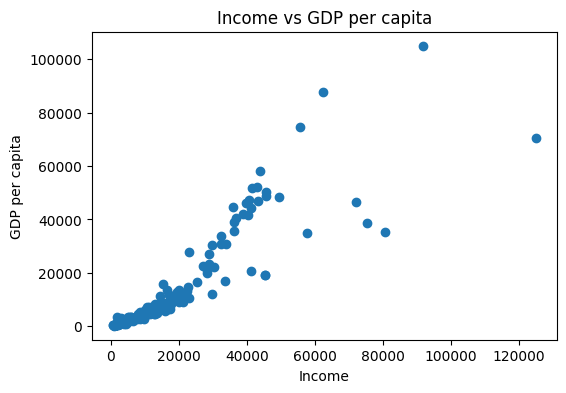

In [17]:
# scatter plot - income vs gdpp
plt.figure(figsize=(6,4))
plt.scatter(df['income'], df['gdpp'])
plt.xlabel("Income")
plt.ylabel("GDP per capita")
plt.title("Income vs GDP per capita")
plt.show()

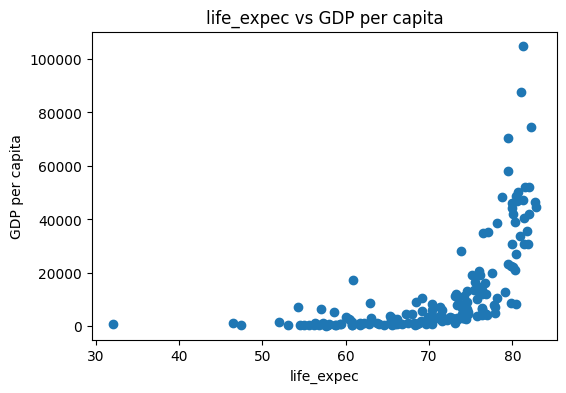

In [18]:
# scatter plot - life expectency vs gdpp
plt.figure(figsize=(6,4))
plt.scatter(df['life_expec'], df['gdpp'])
plt.xlabel("life_expec")
plt.ylabel("GDP per capita")
plt.title("life_expec vs GDP per capita")
plt.show()

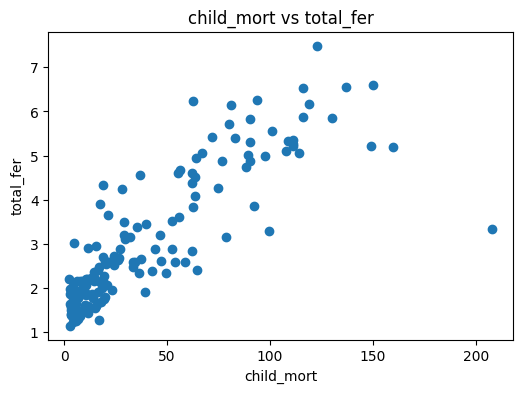

In [19]:
# scatter plot - child_mort vs total_fer
plt.figure(figsize=(6,4))
plt.scatter(df['child_mort'], df['total_fer'])
plt.xlabel("child_mort")
plt.ylabel("total_fer")
plt.title("child_mort vs total_fer")
plt.show()

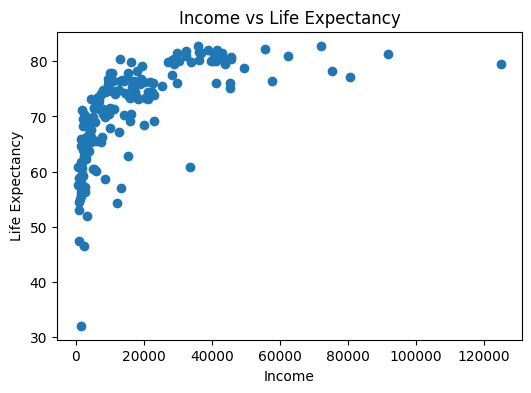

In [20]:
plt.figure(figsize=(6,4))
plt.scatter(df['income'], df['life_expec'])
plt.xlabel("Income")
plt.ylabel("Life Expectancy")
plt.title("Income vs Life Expectancy")
plt.show()

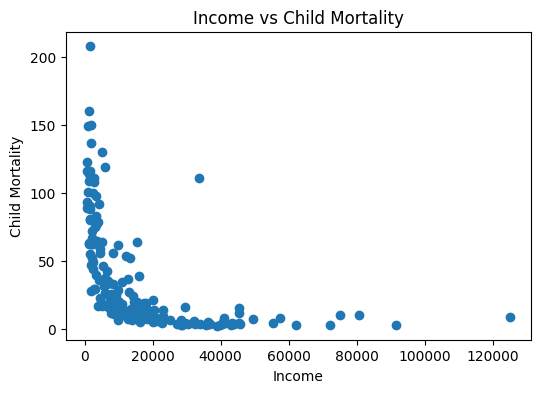

In [21]:
plt.figure(figsize=(6,4))
plt.scatter(df['income'], df['child_mort'])
plt.xlabel("Income")
plt.ylabel("Child Mortality")
plt.title("Income vs Child Mortality")
plt.show()

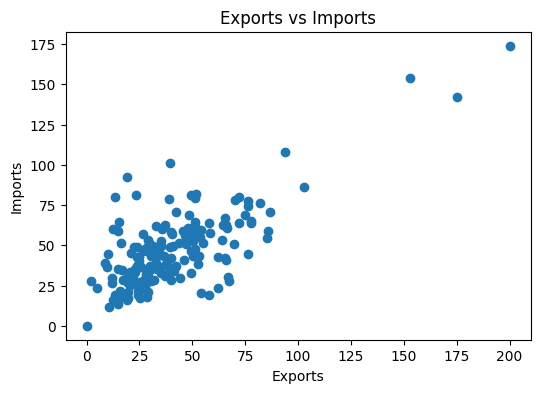

In [22]:
plt.figure(figsize=(6,4))
plt.scatter(df['exports'], df['imports'])
plt.xlabel("Exports")
plt.ylabel("Imports")
plt.title("Exports vs Imports")
plt.show()

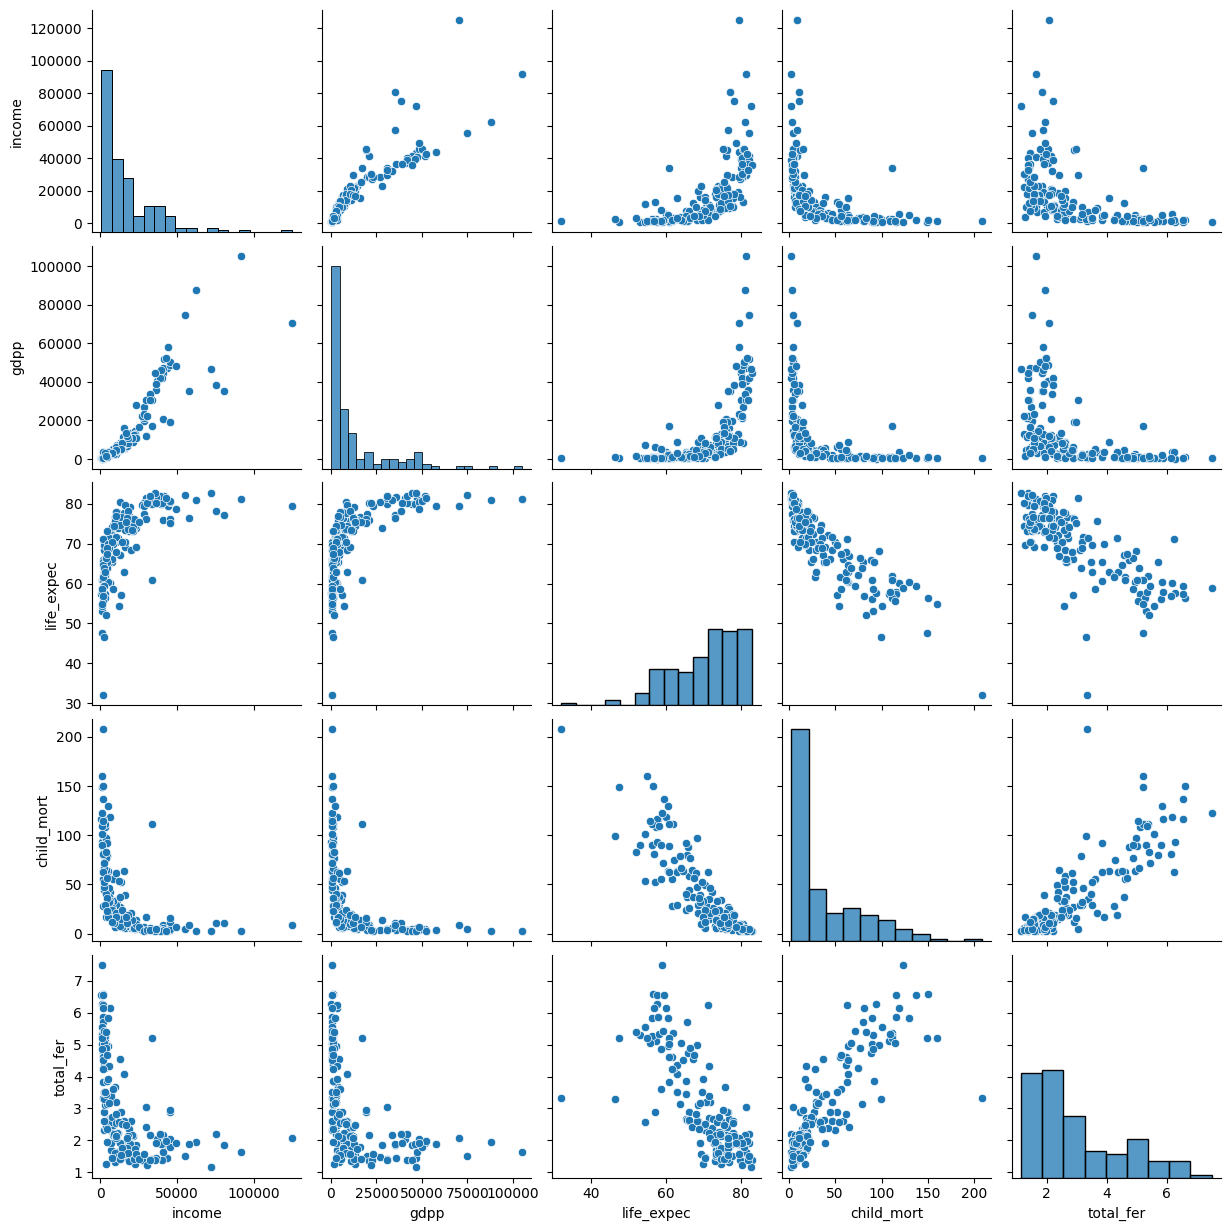

In [23]:
#pair plot
sns.pairplot(df[['income',
                 'gdpp',
                 'life_expec',
                 'child_mort',
                 'total_fer']])
plt.show()

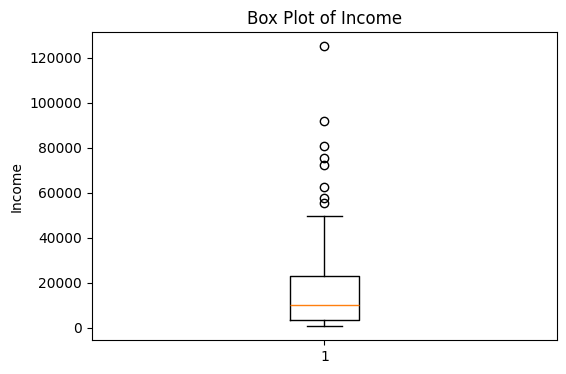

In [24]:
# Box plot

plt.figure(figsize=(6,4))
plt.boxplot(df['income'])
plt.title("Box Plot of Income")
plt.ylabel("Income")
plt.show()

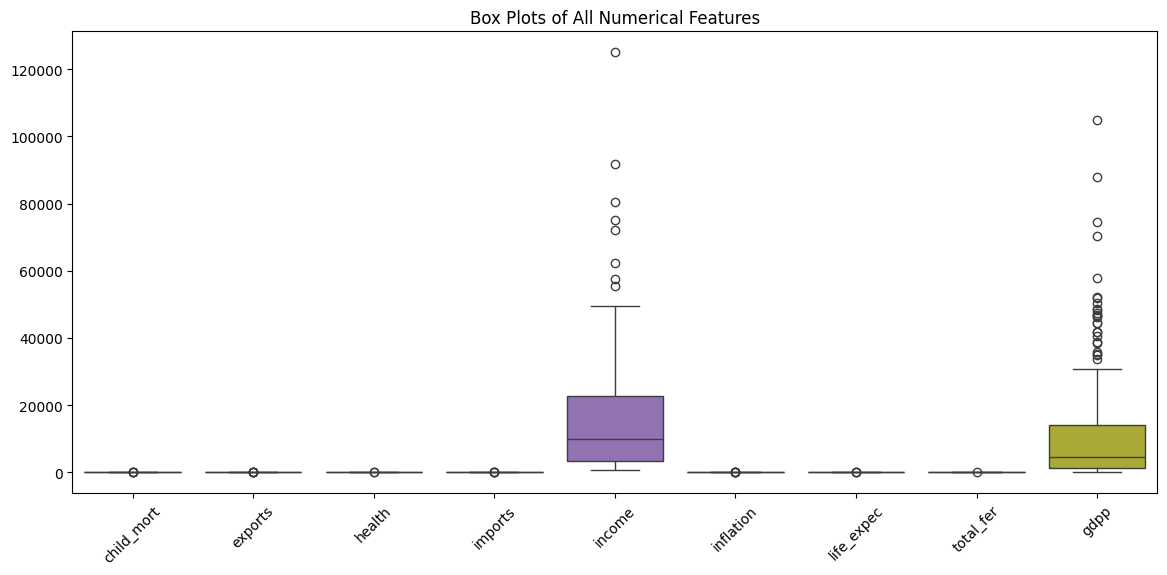

In [25]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df.drop('country', axis=1))
plt.xticks(rotation=45)
plt.title("Box Plots of All Numerical Features")
plt.show()

In [26]:
#Scaling
from sklearn.preprocessing import StandardScaler
#remove country . it is a categorical column
X = df.drop('country', axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


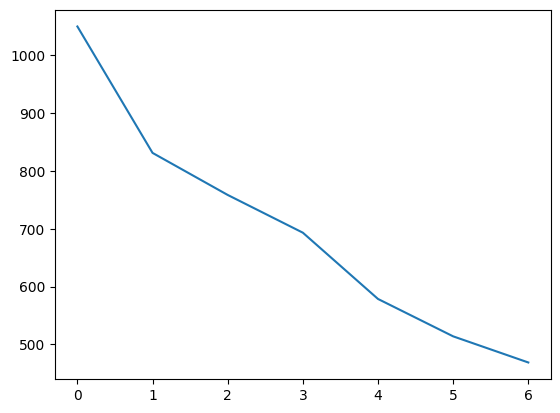

In [27]:
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import linkage
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import cut_tree
#Modelling

#Choose K by elbow method
ssd = []
range_n_clusters = [2, 3, 4, 5, 6, 7, 8]
for num_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=num_clusters, max_iter=50)
    kmeans.fit(X_scaled)

    ssd.append(kmeans.inertia_)

# plot the SSDs for each n_clusters
# ssd
plt.plot(ssd)

It is not clear elbow . so will analyze silhouette score

In [28]:
# silhouette analysis
range_n_clusters = [2, 3, 4, 5, 6, 7, 8]

for num_clusters in range_n_clusters:

    # intialise kmeans
    kmeans = KMeans(n_clusters=num_clusters, max_iter=50)
    kmeans.fit(X_scaled)

    cluster_labels = kmeans.labels_

    # silhouette score
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    print("For n_clusters={0}, the silhouette score is {1}".format(num_clusters, silhouette_avg))

For n_clusters=2, the silhouette score is 0.2662961111870726
For n_clusters=3, the silhouette score is 0.28329575683463126
For n_clusters=4, the silhouette score is 0.3021082505899252
For n_clusters=5, the silhouette score is 0.22101676770423653
For n_clusters=6, the silhouette score is 0.23983213113747684
For n_clusters=7, the silhouette score is 0.2616987616351381
For n_clusters=8, the silhouette score is 0.2051091601767549


for n_cluster 4 , silhouette score is 0.3021082505899252 . so n_cluster will be 4

In [29]:
# final model with k=4
kmeans = KMeans(n_clusters=4, max_iter=50)
kmeans.fit(X_scaled)

KMeans(max_iter=50, n_clusters=4)

In [30]:
kmeans.labels_

array([2, 3, 3, 2, 3, 3, 3, 1, 1, 3, 3, 1, 3, 3, 3, 1, 3, 2, 3, 3, 3, 3,
       3, 1, 3, 2, 0, 3, 2, 1, 3, 2, 2, 3, 3, 3, 2, 0, 2, 3, 2, 3, 1, 1,
       1, 3, 3, 3, 3, 2, 2, 3, 3, 1, 1, 2, 2, 3, 1, 2, 1, 3, 3, 2, 2, 3,
       2, 3, 1, 3, 3, 3, 3, 1, 1, 1, 3, 1, 3, 3, 2, 0, 1, 3, 2, 3, 3, 0,
       0, 3, 3, 1, 3, 2, 2, 3, 3, 2, 1, 2, 3, 0, 3, 3, 3, 3, 2, 2, 2, 3,
       1, 1, 2, 0, 1, 3, 2, 3, 3, 3, 3, 3, 1, 1, 3, 3, 0, 3, 3, 2, 3, 3,
       0, 1, 1, 1, 3, 2, 1, 1, 3, 3, 2, 3, 1, 1, 3, 2, 3, 0, 2, 3, 3, 3,
       3, 0, 3, 1, 1, 1, 3, 3, 3, 3, 3, 2, 2], dtype=int32)

In [31]:
# assign the label
df['cluster_id'] = kmeans.labels_
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster_id
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,3
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,3
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,2
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,3


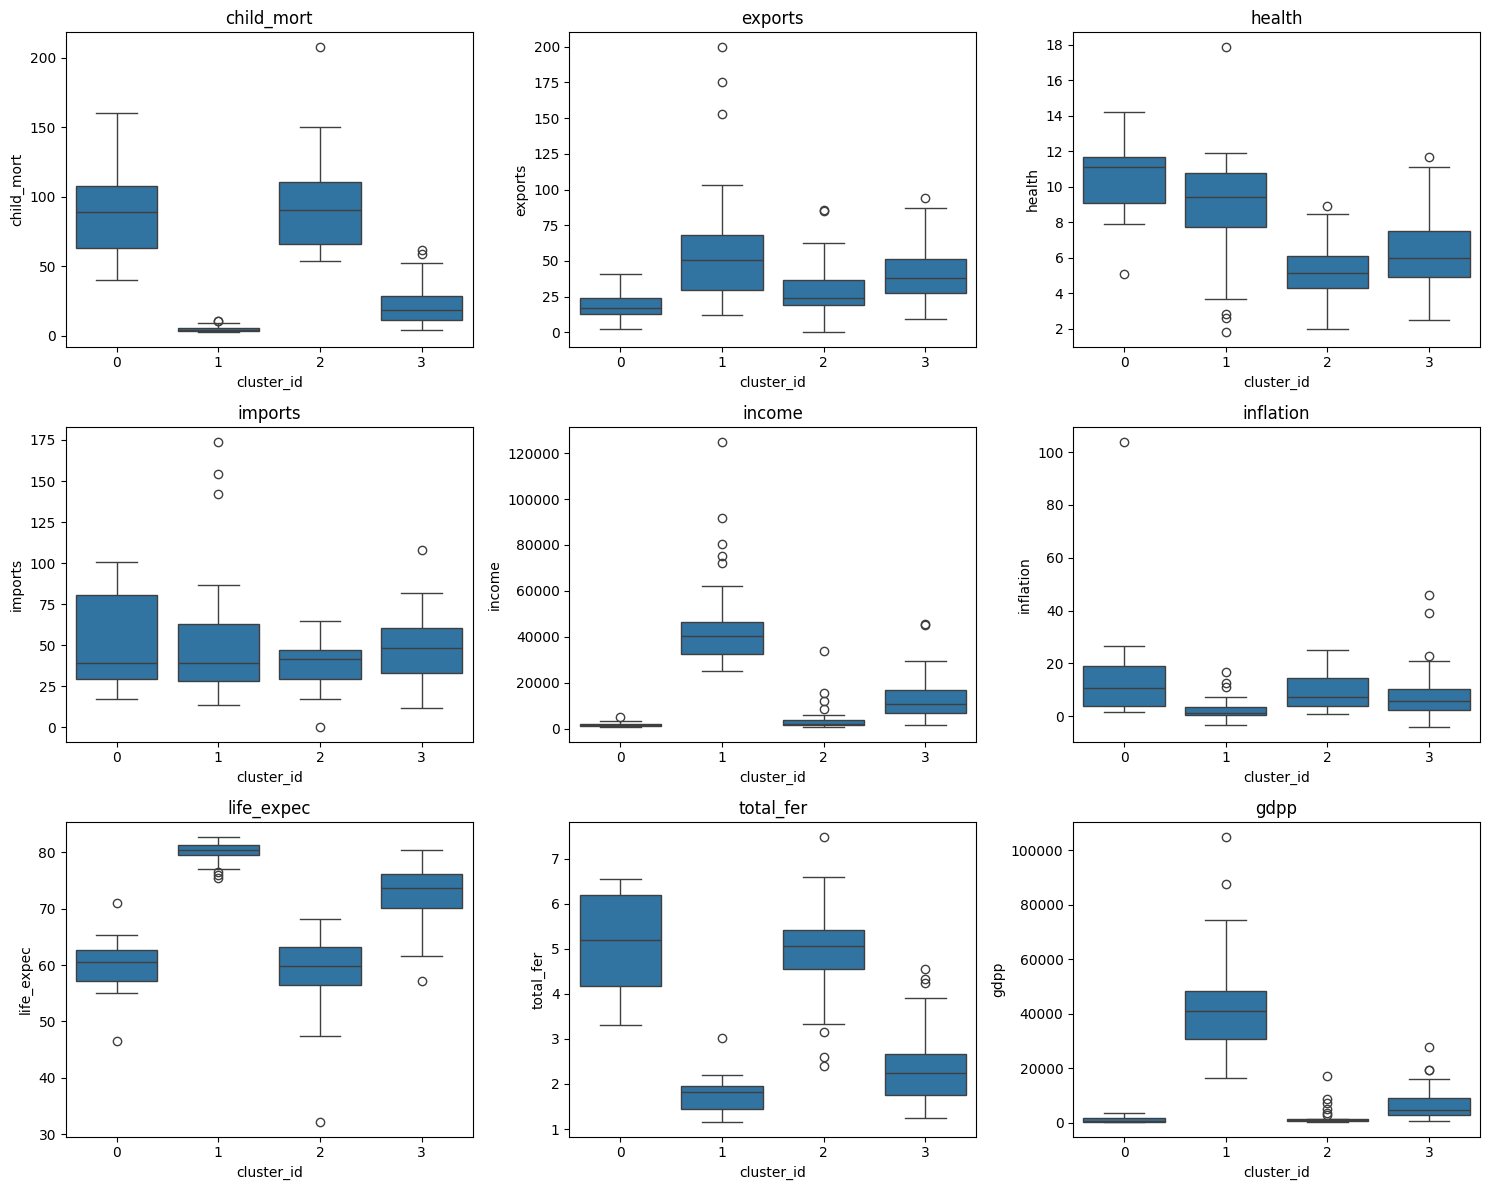

In [35]:
# Numeric columns (excluding country and cluster_id)
features = ['child_mort', 'exports', 'health', 'imports',
            'income', 'inflation', 'life_expec',
            'total_fer', 'gdpp']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(x='cluster_id', y=feature, data=df, ax=axes[i])
    axes[i].set_title(feature)

plt.tight_layout()
plt.show()

In [36]:
cluster_summary = df.groupby('cluster_id').mean(numeric_only=True)
print(cluster_summary)

            child_mort    exports     health    imports        income  \
cluster_id                                                              
0            90.772727  19.883636  10.428182  52.872727   1875.727273   
1             5.000000  58.738889   8.807778  51.491667  45672.222222   
2            94.047222  30.333306   5.139167  38.979608   4047.777778   
3            21.748810  40.950952   6.207381  47.525000  12531.071429   

            inflation  life_expec  total_fer          gdpp  
cluster_id                                                  
0           18.995455   59.690909   5.122727   1263.545455  
1            2.671250   80.127778   1.752778  42494.444444  
2            9.480417   59.252778   4.929444   1929.194444  
3            7.775667   72.720238   2.326190   6569.809524  


Cluster 1 stands out . - developed countries

Lowest child mortality (5)
Highest income (45,672)
Highest GDP per capita (42,494)
Highest life expectancy (80 years)
Lowest fertility (1.75)
Low inflation (2.67)


Cluster 0


Very high child mortality
Very low income
Very low GDP
Low life expectancy
High fertility
High inflation
Interpretation

These are Least Developed Countries.

Cluster 3

Characteristics:

Moderate income
Moderate GDP
Life expectancy around 73
Child mortality around 22
Interpretation

These are Developing Countries.



**Hierarchical Clustering**

In [37]:
X_scaled.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


In [39]:
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster_id
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,3
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,3
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,2
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,3


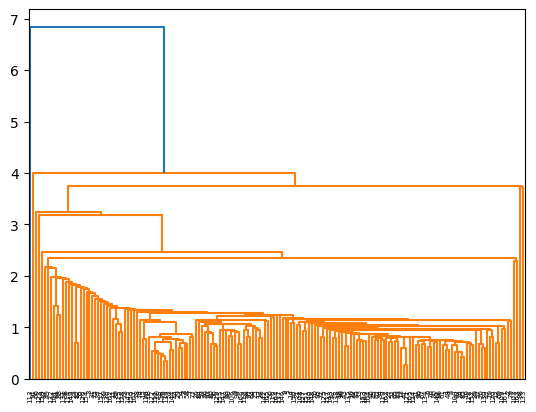

In [40]:
# single linkage
mergings = linkage(X_scaled, method="single", metric='euclidean')
dendrogram(mergings)
plt.show()

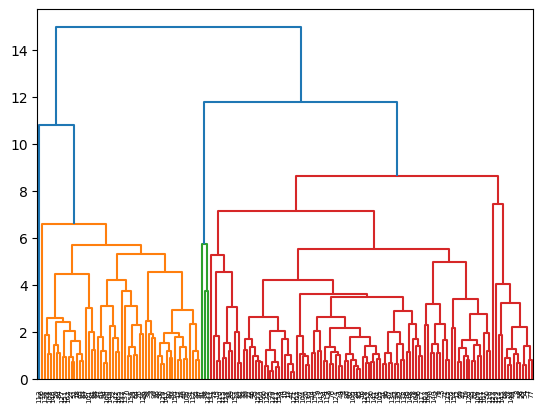

In [41]:
# complete linkage
mergings = linkage(X_scaled, method="complete", metric='euclidean')
dendrogram(mergings)
plt.show()

In [42]:
# 3 clusters
cluster_labels = cut_tree(mergings, n_clusters=4).reshape(-1, )
cluster_labels

array([0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0,
       1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 1, 1, 2, 1, 0, 0, 1, 1, 0, 2, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1,
       0, 2, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0])

In [43]:
# assign cluster labels
df['cluster_labels'] = cluster_labels
df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster_id,cluster_labels
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553,2,0
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090,3,1
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460,3,1
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530,2,0
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200,3,1
